![Machine Learning Lab](banner.jpg)


# Laboratorio 5 Actividad


## Instrucciones generales


1. Esta actividad debe ser entregada por BN y es de carácter individual. No se permite entregar el laboratorio después de la fecha establecida.
2. Al responder las preguntas de las actividades por favor marcar las respuestas con la sección a la que corresponden, por ejemplo: `## Exploración de datos 2.1`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor nombrar el archivo de acuerdo al siguiente formato `{email}_lab5.ipynb`.
4. Si tienen alguna duda pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams

### 0\. Descarga del dataset

Utiliza el siguiente enlace para descargar el dataset de Twitter Tweets Sentiment:

[Descargar Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset)

El dataset contiene tweets reales con clasificación de sentimiento en 3 clases (positive/negative/neutral)

In [1]:
# %%capture
# !mkdir datasets
# !curl -L -o datasets/twitter-tweets-sentiment-dataset.zip https://www.kaggle.com/api/v1/datasets/download/yasserh/twitter-tweets-sentiment-dataset
# !unzip -o datasets/twitter-tweets-sentiment-dataset.zip -d datasets/twitter-tweets-sentiment-dataset
# !ls datasets/telcom-customer-churn-dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report

from sklearn.naive_bayes import MultinomialNB, BernoulliNB

### 1\. Exploración de datos (5%)

1. **Carga del dataset**:
   - Cargar el dataset
   - Seleccionar solo las columnas necesarias: `text` y `sentiment`
   - Eliminar filas con valores faltantes

In [3]:
# Carga del dataset
twitter_sentiment_df = pd.read_csv('../datasets/twitter-tweets-sentiment-dataset/Tweets.csv')

# Seleccion de columnas
twitter_sentiment_df = twitter_sentiment_df[['text','sentiment']]

# Eliminacion de filas con valores faltantes
twitter_sentiment_df = twitter_sentiment_df.dropna()

2. **Análisis exploratorio**:
   - Analizar las primeras 10 filas del dataset limpio
   - Mostrar la distribución de clases (Positive, Negative, Neutral)
   - Verificar el tamaño final del dataset

In [4]:
twitter_sentiment_df.head(10)

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative
5,http://www.dothebouncy.com/smf - some shameles...,neutral
6,2am feedings for the baby are fun when he is a...,positive
7,Soooo high,neutral
8,Both of you,neutral
9,Journey!? Wow... u just became cooler. hehe....,positive


### Analisis exploratorio 1.2
Las primeras filas del dataset muestran publicaciones cortas realizadas en twitter en ingles. Cada publicación tiene contenido textual, que puede hablar de un tema libre como opinion sobre un tema o una oración que hace parte de una interacción en la red social. La columna ´sentiment´ categoriza cada publicación según el sentimiento general de la publicación. Las publicaciones pueden tener un sentimiento 'positive' al tener un sentido de aprobación o satisfacción como la frase **'Journey!? Wow... u just became cooler.'**; 'negative' si, por el contrario, expresa insatisfacción, enojo o crítica, por ejemplo, **'Sooo SAD I will miss you here in San Diego!!!'**. Si la publicación no tiende hacia una de estas dos categorias, su sentido es ´neutral´, por ejemplo, **'Both of you'**.

A continucación se presenta la distribución de las publicación sobre cada clase.

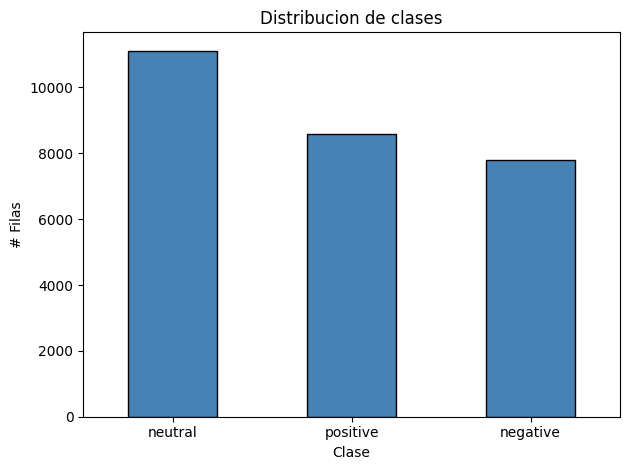

In [5]:
# Distribucion de clases
twitter_sentiment_df['sentiment'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')

# Configuración de la grafica
plt.title('Distribucion de clases')
plt.xlabel('Clase')
plt.ylabel('# Filas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El dataset 'Twitter Tweets Sentiment' contiene un total de 27.480 publicaciones y dos columnas, las cuales contienen el contenido de la publicación ('text') y la categoria de sentido ('sentiment')

In [6]:
rows, cols = twitter_sentiment_df.shape

print(f'El dataset tiene {rows} filas y {cols} columnas')

El dataset tiene 27480 filas y 2 columnas


### 2\. Procesamiento de datos (15%)

Los algoritmos de Machine Learninng no trabajan directamente con texto. Por eso debemos convertir palabras en vectores numéricos mediante técnicas como [Bag-of-Words](https://www.ibm.com/think/topics/bag-of-words), un método que cuantifica la frecuencia de palabras en documentos de texto. Esto transforma frases como "muy muy mala pelicula" en vectores como [0, 2, 1, 1, 0, 0, ..., 0] donde cada posición representa una palabra del vocabulario.

Scikit-learn provee una clase [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) que convierte una colección de documentos a una matriz de conteo de palabras. Adicionalmente, realiza procesamiento convirtiendo el texto a minúsculas y eliminando palabras que no aportan valor a la predicción.

1. Divide el dataset en 80/20 con `train_test_split()`, `stratify=sentiment`, y `random_state=42`.
2. Usa CountVectorizer usando `lowercase=True` y `stop_words='english'` e inicializalo con el conjunto de entrenamiento usando `fit_transform`
   
   ```python
   from sklearn.feature_extraction.text import CountVectorizer
   
   # Vectorizador automático
   vectorizer = CountVectorizer(lowercase=True, stop_words='english')
   
   ...
   ```
3. Compara 3 textos originales con el texto procesado por `CountVectorizer`.

In [7]:
# Separación de variables
X = twitter_sentiment_df.drop('sentiment',axis=1)
y = twitter_sentiment_df['sentiment']

# Separa los conjuntos de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=twitter_sentiment_df['sentiment'],random_state=42)

# vectorizador
vectorizer = CountVectorizer(lowercase=True, stop_words='english')

X_train_vectorized = vectorizer.fit_transform(X_train['text'])
X_test_vectorized = vectorizer.transform(X_test['text'])

In [8]:
# Comparación de formatos de los documentos
# primeros tres documentos en formato original
X_train[:3]

,text
16595,Press `Ctrl` on bottom right. It`s there. KY
15039,ah remember the days when you`d sleep in until...
1804,my momma is comin 2night ! 2morrow tennis day...


In [9]:
# primeros tres documentos en formato vectorizado
print(X_train_vectorized[:3,:])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 24 stored elements and shape (3, 22678)>
  Coords	Values
  (0, 15824)	1
  (0, 5983)	1
  (0, 16933)	1
  (0, 11777)	1
  (1, 2131)	1
  (1, 16668)	1
  (1, 6262)	1
  (1, 18200)	1
  (1, 14188)	1
  (1, 9530)	1
  (1, 6621)	1
  (1, 20140)	1
  (1, 9187)	1
  (1, 8098)	1
  (1, 12157)	1
  (1, 12426)	1
  (2, 13433)	1
  (2, 5400)	1
  (2, 343)	1
  (2, 337)	1
  (2, 19742)	1
  (2, 6256)	1
  (2, 13855)	1
  (2, 22540)	1


### Comparación de tres documentos 2.3
Como se puede observar en las celdas anteriores, el formato original del dataset es textual, del cual su contenido es facilmente legible y entendible. Sin embargo, el vectorizador CountVectorizer nos devuelve una matriz dispersa, Esto sucede porque el vector ha extraido el vocabulario a nivel de palabra del corpus del dataset que, en este caso es de 22678 palabras, y representa cada documento con un vector. Este vector contiene el conteo de cada palabra del vocabulario que está contenida en el documento. Al ser documentos cortos, probablemente no contengan muchas de las palabras del vocabulario, lo que ocasiona que su representacíon vectorial esté compuesta en su mayoria por valores cero. Para optimizar el uso de memoria y computo, se usa matrices dispersas. En la celda anterior, se imprime en consola las coordenadas de los valores de los vectores que son diferentes a cero dentro de la matriz y y su valor, el cual es el numero de veces que la palabra aparece en el documento.

### 3\. Entrenamiento de Naïve Bayes (60%)

1. **Entrenamiento de modelos**:
   - Entrena un modelo de [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) (para frecuencias de palabras)
   - Entrena un modelo de [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (para presencia/ausencia de palabras)

2. **Evaluación y métricas**:
   - Reporta **accuracy**, **precision**, **recall**, y **F1-score** de cada modelo

3. **Análisis comparativo**:
   - ¿Qué modelo obtuvo el mejor rendimiento?

In [10]:
# Entrenamiento del modelo
multinomialNB = MultinomialNB()

multinomialNB.fit(X_train_vectorized, y_train)
print(multinomialNB.predict(X_test_vectorized))

['negative' 'negative' 'negative' ... 'negative' 'neutral' 'positive']


In [11]:
# Evaluación del modelo MultinomialNB
y_pred = multinomialNB.predict(X_test_vectorized)

print('Resultado de evaluación del modelo MultinomialNB:\n')
print(classification_report(y_test,y_pred))

Resultado de evaluación del modelo MultinomialNB:

              precision    recall  f1-score   support

    negative       0.68      0.60      0.64      1556
     neutral       0.59      0.67      0.63      2223
    positive       0.70      0.65      0.68      1717

    accuracy                           0.64      5496
   macro avg       0.66      0.64      0.65      5496
weighted avg       0.65      0.64      0.64      5496



In [12]:
# Entrenamiento del modelo
bernoulliNB = BernoulliNB()

bernoulliNB.fit(X_train_vectorized, y_train)
print(bernoulliNB.predict(X_test_vectorized))

['neutral' 'neutral' 'negative' ... 'negative' 'neutral' 'positive']


In [13]:
# Evaluación del modelo BernoulliNB
y_pred = bernoulliNB.predict(X_test_vectorized)

print('Resultado de evaluación del modelo BernoulliNB:\n')
print(classification_report(y_test,y_pred))

Resultado de evaluación del modelo BernoulliNB:

              precision    recall  f1-score   support

    negative       0.74      0.43      0.54      1556
     neutral       0.54      0.82      0.66      2223
    positive       0.79      0.57      0.66      1717

    accuracy                           0.63      5496
   macro avg       0.69      0.61      0.62      5496
weighted avg       0.67      0.63      0.62      5496



### Análisis comparativo 3.3
El mejor modelo para esta tarea fue **MultinomialNB**. A pesar de que el modelo BernoulliNB obtuvo mejores metricas en precision, al ser un dataset con clases desbalanceadas, una metrica mas objetiva es el F1 score que tiene en cuenta la precision y el recall. En esta metrica, el modelo MultinomialNB obtuvo mejores resultados tanto en macro-avg como weighted avg. Además, el modelo MultinomialNB obtuvo un mejor score en accuracy.

### 4\. Predicciones (20%)

1. Realiza 3 predicciones con el mejor modelo sobre nuevos tweets que demuestren como clasifica el modelo el texto para cada una de las clases.

In [14]:
# Predicción con tres tweets nuevos
tweets = [
  "Just got my hands on the new Pixel 9 and I'm obsessed! 😍 The camera quality is on another level and the battery actually lasts all day. Best upgrade I've made in years! #Tech #Pixel9 #Happy",
  "Third time this week the app has frozen while I was trying to check out. 🙄 Seriously @CustomerSupport, your latest update is a total disaster. Fix your servers! #Frustrated #BadService",
  "The latest software update for the Model 3 was released this morning. It includes changes to the regenerative braking settings and a few minor UI adjustments. #Tesla #SoftwareUpdate"
]

#vectorizacion de los documentos
tweets_vectorized = vectorizer.transform(tweets)

# prediccion con el mejor modelo
multinomialNB.predict( tweets_vectorized )

array(['positive', 'negative', 'neutral'], dtype='<U8')